## <span style="color:blue"> Lezione 2 </span>



In [2]:

import matplotlib.pyplot as plt
import numpy as np
import scipy.optimize as scipy


### <span style="color:DodgerBlue"> Esercizio 2.1  </span>

Si stima il valore dell'integrale $I=2/\pi \int_0^1 \cos(\pi /2 x) \, \mathrm{d}x =1 $ con il metodo Montecarlo. Dapprima, si campiona $x$ con una distribuzione uniforme tra $[0,1)$, dopodichè si sfrutta il metodo dell'importance sampling: $$ I=\int_0^1 \frac{2/\pi \cos(\pi /2 x)}{p(x)} p(x)  \, \mathrm{d}x $$ 

con $p(x)$ una distribuzione di probabilità. Per eseguire l'esercizio è stato scelto $p(x)=2(1-x)$ su $[0,1)$. Per campionarla si può invertire la distribuzione cumulativa, ottenendo che, dato $u$ estratto uniformemente da $[0,1)$, $x=1-\sqrt{1-u}$ segue la distribuzione richiesta. 

Si sono campionati $M=10000$ punti, suddivisi in $N=100$ blocchi. 


Nella cella sottostante è riportato il codice che genera il grafico del confronto della stima dell'integrale calcolata con i due metodi. 

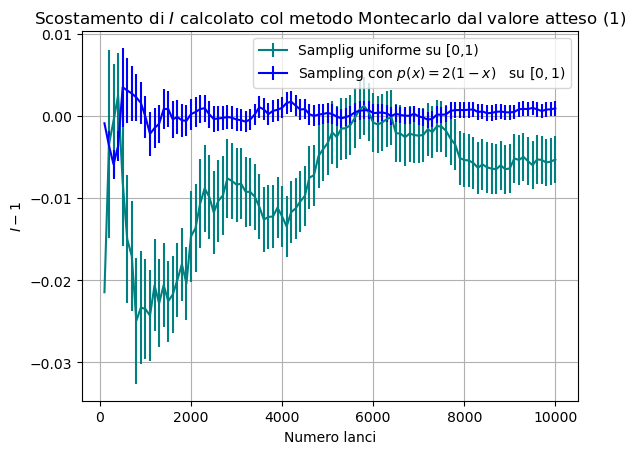

In [3]:
M=10000 #numero estrazioni
N=100 #numero blocchi

I_u,error_u,I_is,error_is=np.loadtxt("l_02_es_1/results.csv", usecols=(0,1,2,3), delimiter=',', unpack='true',skiprows=1) #carica i dati, saltando la riga del titolo

n=np.arange(1,N+1) #progressivo dei blocchi
n*=int(M/N) #numero estrazioni 

#traccia il grafico dello scostamento dell'integrale dal valore atteso in funzione del numero di blocchi, con le rispettive barre di errore
plt.errorbar(n,I_u-1,error_u,color="teal") #sampling uniforme
plt.errorbar(n,I_is-1,error_is,color="blue") #importance sampling


plt.title(fr"Scostamento di $I$ calcolato col metodo Montecarlo dal valore atteso (1)")
plt.xlabel("Numero lanci")
plt.ylabel(rf"$I-1$")
plt.legend(["Samplig uniforme su [0,1)", rf"Sampling con $p(x)=2(1-x)$   su $ [0,1)$"])
plt.grid(True)
plt.show()

### <span style="color:DodgerBlue"> Esercizio 2.3 </span>

Sono dati due random walk in 3D: 
1. su una griglia di passo $a=1$. Ad ogni step il random walk può muoversi avanti o indietro di un passo a, in ciascuna direzione cartesiana, con egual probabilità
2. nel continuo. Ad ogni step il random walk si muoverà di un passo $\vec{r}=(1,\theta,\phi)$ in coordinate sferiche, con $\theta \in[0,\pi)$ e $\phi \in[0,2\pi)$ estratti da una distribuzione uniforme


Per $M=10000$ volte, suddivise in $N=100$ blocchi vengono generati i RW 1. e 2. con $R=100$ steps ciascuno. Si calcola quindi: $$ A(i)=\sqrt{<|\vec{r}_i|^2>} $$ per ogni step $i\in [1,100]$. La media è effettuata sui random walk del blocco, e la quantità trovata viene poi mediata su tutti i blocchi. Dalla media dei quadrati di $A(i)$ dei diversi blocchi si ricava anche la deviazione standard. 

Nella cella sottostante è presente il codice che genera la rappresentazione dei risultati trovati ($A(i)$ in funzione di $i$) e il fit alla funzione attesa $A(i) \sim k \sqrt{i}$ 



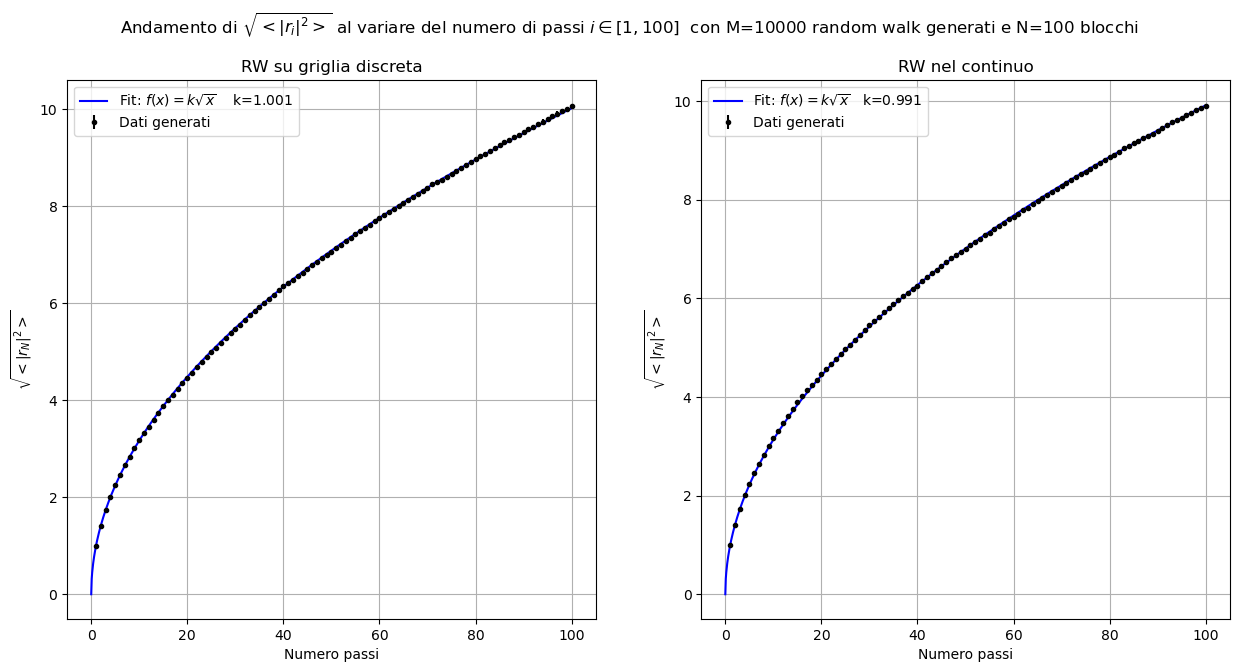

In [9]:

#funzione per il fit
def f(x,k): 
    return k*np.sqrt(x)

data_grid,error_grid,data_cont,error_cont=np.loadtxt("l_02_es_2/results.csv", usecols=(0,1,2,3), delimiter=',', unpack='true',skiprows=1) #carica i dati, saltando la riga del titolo


fig,axs=plt.subplots(1,2,figsize=[15,7])


M=10000 #numero random walk generati
N=100 #numero blocchi
R=100#numero step 


n=np.arange(1,R+1) #progressivo del numero di step 


#Random walk su griglia

axs[0].errorbar(n,data_grid,error_grid,marker=".",linestyle="none",color="black") #plot dati

#fit e relativo plot
k_fit=scipy.curve_fit(f,n,data_grid)[0][0] #fitta i dati alla funzione k*sqrt(x) e restituisce il parametro k
x=np.linspace(0,R,R*10)
axs[0].plot(x,f(x,k_fit),color="blue") 

axs[0].set_title(fr"RW su griglia discreta")
axs[0].set_xlabel("Numero passi")
axs[0].set_ylabel(r"$\sqrt{<|r_N|^2>}$")
axs[0].legend([rf"Fit: $f(x)=k \sqrt{{x}} $    k={k_fit:.3f} ","Dati generati"])
axs[0].grid(True)


#Random walk nel continuo 

axs[1].errorbar(n,data_cont,error_cont,marker=".",linestyle="none",color="black") #plot dati

#fit e relativo plot
k_fit=scipy.curve_fit(f,n,data_cont)[0][0] #fitta i dati alla funzione k*sqrt(x) e restituisce il parametro k
x=np.linspace(0,R,R*10)
axs[1].plot(x,f(x,k_fit),color="blue")

axs[1].set_title(fr"RW nel continuo")
axs[1].set_xlabel("Numero passi")
axs[1].set_ylabel(r"$\sqrt{<|r_N|^2>}$")
axs[1].legend([ rf"Fit: $f(x)=k \sqrt{{x}} $   k={k_fit:.3f}","Dati generati"])
axs[1].grid(True)


plt.suptitle(rf"Andamento di $\sqrt{{<|r_i|^2>}}$ al variare del numero di passi $i\in [1,{R}]$  con M={M} random walk generati e N={N} blocchi")
plt.show()

Le barre di errore sono troppo piccole per essere visualizzate: vengono infatti coperte dall'estensione del marker utilizzato.